<a href="https://colab.research.google.com/github/gohyongxuan/Reports/blob/main/Decision_Trees_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn import tree
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Baseball Data from kaggle

In [ ]:
df = pd.read_csv('baseball.csv')

In [ ]:
df.fillna(0, inplace=True)
df['OPS'] = df['OBP'] + df['SLG']
df['OOPS'] = df['OOBP'] + df['OSLG']
df['Year'] = df['Year'].apply(lambda x: int(x))
df.drop(['League','Team'],axis=1,inplace=True)
df.head()

,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG,OPS,OOPS
0,2012,734,688,81,0.328,0.418,0.259,0,0.0,0.0,162,0.317,0.415,0.746,0.732
1,2012,700,600,94,0.320,0.389,0.247,1,4.0,5.0,162,0.306,0.378,0.709,0.684
2,2012,712,705,93,0.311,0.417,0.247,1,5.0,4.0,162,0.315,0.403,0.728,0.718
3,2012,734,806,69,0.315,0.415,0.260,0,0.0,0.0,162,0.331,0.428,0.730,0.759
4,2012,613,759,61,0.302,0.378,0.240,0,0.0,0.0,162,0.335,0.424,0.680,0.759


In [ ]:
# df1 = df.drop(['Year', 'RS', 'RA', 'W', 'OBP', 'SLG', 'RankSeason', 'RankPlayoffs', 'G'], axis=1)
df1 = df.drop(['Year', 'RS', 'RA', 'W', 'RankSeason', 'RankPlayoffs', 'G', 'OOPS', 'OPS'], axis=1)
df2 = df.drop(['Year', 'RS', 'RA', 'W', 'RankSeason', 'RankPlayoffs', 'G', 'OBP', 'SLG', 'OOBP', 'OSLG'], axis=1)
df2.head()

,BA,Playoffs,OPS,OOPS
0,0.259,0,0.746,0.732
1,0.247,1,0.709,0.684
2,0.247,1,0.728,0.718
3,0.260,0,0.730,0.759
4,0.240,0,0.680,0.759


<Axes: xlabel='OOPS', ylabel='OPS'>

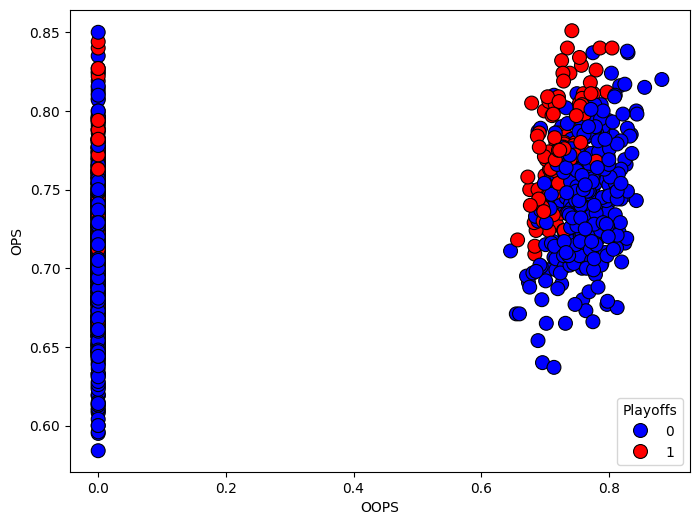

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='OOPS', y='OPS', hue='Playoffs', palette={0: 'blue', 1: 'red'}, s=100, edgecolor='black')

In [ ]:
X = df1.drop(columns=['Playoffs'])
y = df1['Playoffs']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_2 = df2.drop(columns=['Playoffs'])
y_2 = df2['Playoffs']
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42)


Decision Tree Classifier with sklearn

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=3)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [ ]:
y_pred1 = dt_model.predict(X_test)

print("Classification Report for Decision Tree Classifier:")
print(classification_report(y_test, y_pred1))

accuracy1 = accuracy_score(y_test, y_pred1)
print(f"Accuracy: {accuracy * 100:.2f}%")

Classification Report for Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       203
           1       0.62      0.18      0.28        44

    accuracy                           0.83       247
   macro avg       0.73      0.58      0.59       247
weighted avg       0.81      0.83      0.79       247

Accuracy: 78.14%


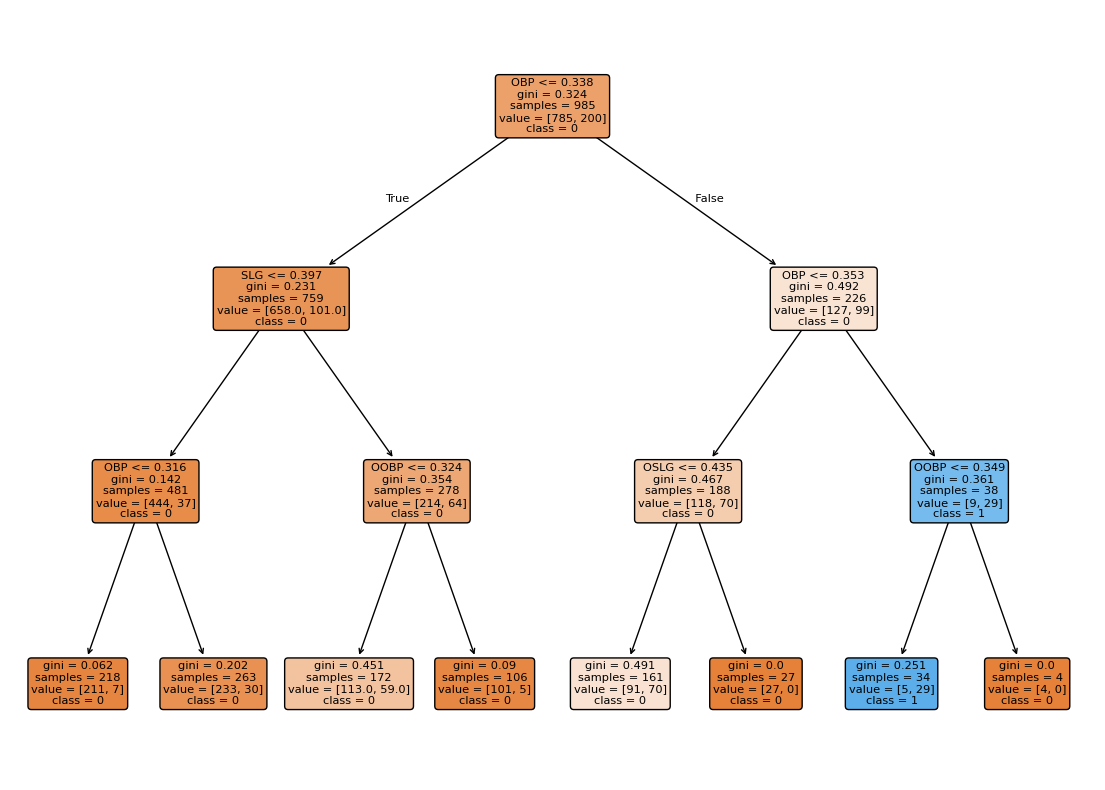

In [ ]:
plt.figure(figsize=(14, 10))
tree.plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=[str(label) for label in y.unique()], rounded=True)
plt.show()

Manual Decision Tree Classifier

In [ ]:
def calculate_entropy(y):
    classes = y.value_counts()
    probabilities = classes / len(y)
    entropy = -np.sum(probabilities * np.log2(probabilities))
    return entropy

def information_gain(X, y, feature, value):
    left_y = y[X[feature] <= value]
    right_y = y[X[feature] > value]
    left_entropy = calculate_entropy(left_y)
    right_entropy = calculate_entropy(right_y)
    weighted_entropy = (len(left_y) / len(y)) * left_entropy + (len(right_y) / len(y)) * right_entropy
    gain = calculate_entropy(y) - weighted_entropy
    return gain

def build_tree(X, y, max_depth=3, min_samples_split=2, current_depth=0):
    if current_depth == max_depth or len(X) < min_samples_split or len(y.unique()) == 1:
        return {'leaf': True, 'prediction': y.mode()[0]}
    best_feature = None
    best_value = None
    best_gain = -1
    for feature in X.columns:
        possible_values = X[feature].unique()
        for value in possible_values:
            gain = information_gain(X, y, feature, value)
            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_value = value
    if best_gain <= 0:
        return {'leaf': True, 'prediction': y.mode()[0]}
    left_mask = X[best_feature] <= best_value
    right_mask = ~left_mask
    left_X, right_X = X[left_mask], X[right_mask]
    left_y, right_y = y[left_mask], y[right_mask]
    left_tree = build_tree(left_X, left_y, max_depth, min_samples_split, current_depth + 1)
    right_tree = build_tree(right_X, right_y, max_depth, min_samples_split, current_depth + 1)
    return {'leaf': False, 'feature': best_feature, 'value': best_value, 'left': left_tree, 'right': right_tree}

def predict_tree(tree, X):
    if tree['leaf']:
        return tree['prediction']
    feature = tree['feature']
    value = tree['value']
    if X[feature] <= value:
        return predict_tree(tree['left'], X)
    else:
        return predict_tree(tree['right'], X)

def print_tree(tree, depth=0):
    if tree['leaf']:
        print(f"{'  ' * depth}Prediction: {tree['prediction']}")
    else:
        print(f"{'  ' * depth}Feature: {tree['feature']} <= {tree['value']}")
        print(f"{'  ' * depth}Left:")
        print_tree(tree['left'], depth + 1)
        print(f"{'  ' * depth}Right:")
        print_tree(tree['right'], depth + 1)


In [ ]:
tree_model = build_tree(X_train, y_train, max_depth=3, min_samples_split=2)

In [ ]:
y_pred2 = X_test.apply(lambda row: predict_tree(tree_model, row), axis=1)

accuracy2 = (y_pred2 == y_test).mean()
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 78.14%


In [ ]:
print_tree(tree_model)

Feature: SLG <= 0.394
Left:
  Feature: OBP <= 0.315
  Left:
    Feature: SLG <= 0.362
    Left:
      Prediction: 0
    Right:
      Prediction: 0
  Right:
    Feature: SLG <= 0.363
    Left:
      Prediction: 0
    Right:
      Prediction: 0
Right:
  Feature: OSLG <= 0.422
  Left:
    Feature: OBP <= 0.342
    Left:
      Prediction: 0
    Right:
      Prediction: 1
  Right:
    Feature: OBP <= 0.354
    Left:
      Prediction: 0
    Right:
      Prediction: 1


Random Forest Classifier

In [ ]:
rf_model = RandomForestClassifier(n_estimators=1000, max_depth=3)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, n_estimators=1000)

In [ ]:
y_pred3 = rf_model.predict(X_test)

print("Classification Report for Random Forest Classifier:")
print(classification_report(y_test, y_pred3))

accuracy3 = accuracy_score(y_test, y_pred3)
print(f"Accuracy: {accuracy * 100:.2f}%")

Classification Report for Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91       203
           1       0.61      0.25      0.35        44

    accuracy                           0.84       247
   macro avg       0.73      0.61      0.63       247
weighted avg       0.81      0.84      0.81       247

Accuracy: 78.14%


In [ ]:
rf_model = RandomForestClassifier(n_estimators=1000, max_depth=3)
rf_model.fit(X_train_2, y_train_2)

RandomForestClassifier(max_depth=3, n_estimators=1000)

In [ ]:
y_pred4 = rf_model.predict(X_test_2)

print("Classification Report for Random Forest Classifier:")
print(classification_report(y_test_2, y_pred4))

accuracy4 = accuracy_score(y_test_2, y_pred4)
print(f"Accuracy: {accuracy * 100:.2f}%")

Classification Report for Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.84      0.98      0.90       203
           1       0.55      0.14      0.22        44

    accuracy                           0.83       247
   macro avg       0.69      0.56      0.56       247
weighted avg       0.79      0.83      0.78       247

Accuracy: 78.14%
